<a href="https://colab.research.google.com/github/nihalhussain555/Email-Scam-Detection/blob/main/Email_Spam.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [34]:
df = pd.read_csv('/content/spam.csv',encoding='latin1')

In [35]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [37]:
df.drop( columns=['Unnamed: 2' , 'Unnamed: 3' , 'Unnamed: 4' ] , inplace = True)

In [38]:
df.rename( columns = { 'v1' : 'target' , 'v2' : 'text' } , inplace = True)

In [39]:
from sklearn.preprocessing import LabelEncoder
encorder = LabelEncoder()
df['target'] = encorder.fit_transform(df['target'])

In [40]:
df.isnull().sum()

,0
target,0
text,0


In [41]:
df.duplicated().sum()

np.int64(403)

In [42]:
df = df.drop_duplicates(keep = 'first' )

In [43]:
df.shape

(5169, 2)

In [44]:
values = df['target'].value_counts()
total = values.sum()
percent_0 = ( values[0] / total ) * 100;
percent_1 = ( values[1] / total ) * 100;
print( '% of non spam: ' , percent_0)
print( '% of spam: ' , percent_1)

% of non spam:  87.3669955503966
% of spam:  12.633004449603405


In [45]:
df['num_characters'] = df['text'].apply(len)
df['num_words'] = df['text'].apply(lambda x: len(nltk.word_tokenize(x)))
df['num_sentence'] = df['text'].apply(lambda x:len(nltk.sent_tokenize(x)))
df[['num_characters' , 'num_words' , 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [46]:
df[df['target'] == 0 ][['num_characters' , 'num_words' , 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [47]:
df[df['target'] == 1 ][['num_characters' , 'num_words' , 'num_sentence']].describe()

,num_characters,num_words,num_sentence
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


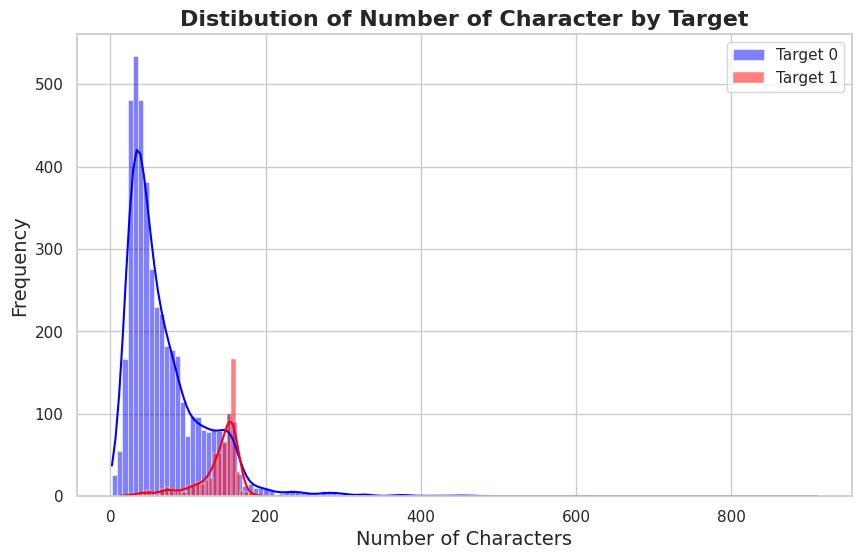

In [56]:
import seaborn as sns
plt.figure(figsize=( 10 , 6))
sns.histplot( df[ df['target'] == 0 ] ['num_characters'],color = 'blue' , label = 'Target 0' , kde = True )
sns.histplot( df[ df['target'] == 1 ] ['num_characters'],color = 'red' , label = 'Target 1' , kde = True )

plt.xlabel( 'Number of Characters' , fontsize =  14)
plt.ylabel( 'Frequency' , fontsize =  14)
plt.title( 'Distibution of Number of Character by Target' , fontsize = 16 , fontweight = 'bold')
plt.legend()
sns.set( style = 'whitegrid')
plt.show()

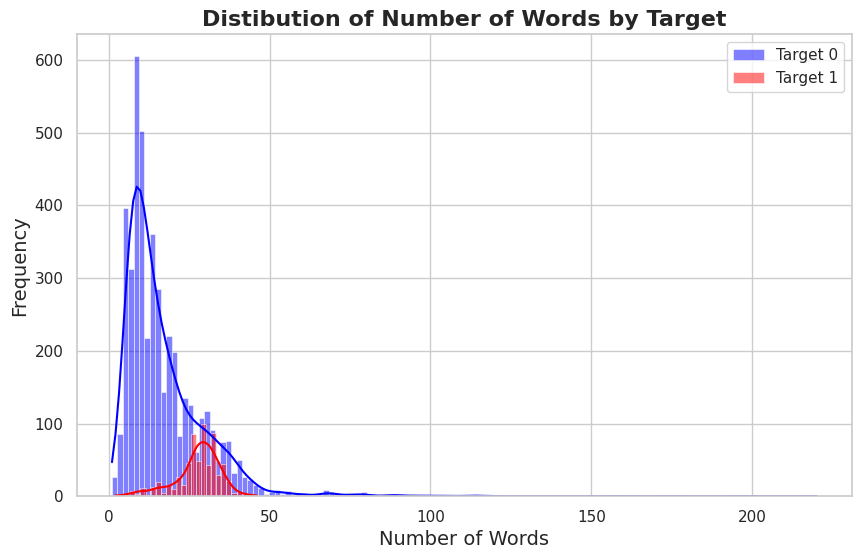

In [57]:
plt.figure(figsize=( 10 , 6))
sns.histplot( df[ df['target'] == 0 ] ['num_words'],color = 'blue' , label = 'Target 0' , kde = True )
sns.histplot( df[ df['target'] == 1 ] ['num_words'],color = 'red' , label = 'Target 1' , kde = True )

plt.xlabel( 'Number of Words' , fontsize =  14)
plt.ylabel( 'Frequency' , fontsize =  14)
plt.title( 'Distibution of Number of Words by Target' , fontsize = 16 , fontweight = 'bold')
plt.legend()
sns.set( style = 'whitegrid')
plt.show()

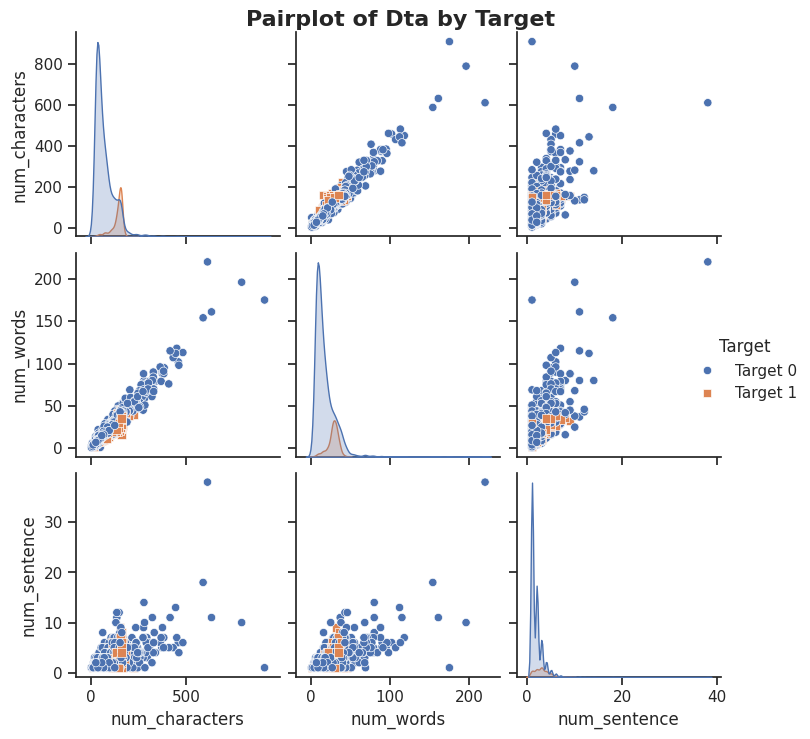

In [60]:
sns.set( style = 'ticks' , color_codes = True)
g = sns.pairplot( df , hue = 'target' , diag_kind = 'kde' , markers = ['o' , 's'])
g.fig.suptitle( 'Pairplot of Dta by Target' , fontsize = 16 , fontweight = 'bold')
plt.subplots_adjust(top = 0.95)
g._legend.set_title('Target')
for t , l in zip( g._legend.texts , ['Target 0' , 'Target 1']) :
  t.set_text(l)
plt.show()

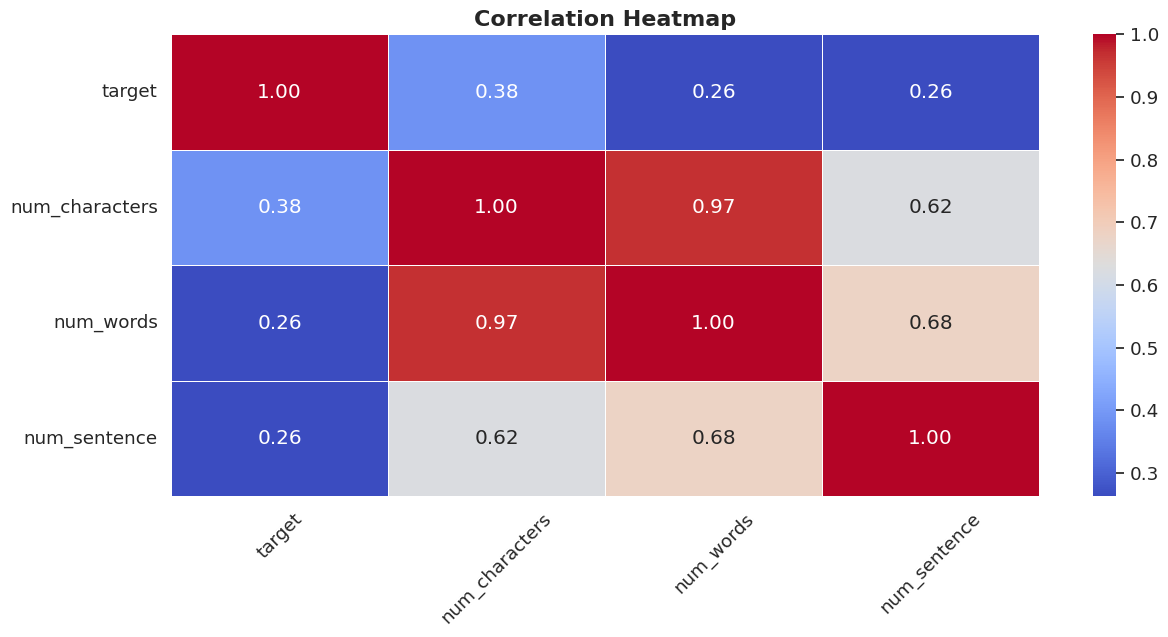

In [65]:
correlation_matrix = df[['target' , 'num_characters' , 'num_words' , 'num_sentence']].corr()
plt.figure( figsize=( 14 , 6))
sns.set( font_scale = 1.2 )
sns.heatmap( correlation_matrix , annot = True , cmap = 'coolwarm' , linewidths = 0.5 , fmt = '.2f')
plt.title( 'Correlation Heatmap' , fontsize = 16 , fontweight = 'bold')
plt.xticks(rotation = 45 )
plt.show()

In [72]:
import nltk
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
import string

ps = PorterStemmer()

def transform_text(text):
    text = text.lower()
    text = nltk.word_tokenize(text)

    y = []
    for i in text:
        if i.isalnum():
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)

    text = y[:]
    y.clear()

    for i in text:
        y.append(ps.stem(i))

    return " ".join(y)
df['transform_text'] = df['text'].apply(transform_text)

In [73]:
transform_text( 'Go around until jurong poins, crazy....Available only in bugis n great')

'go around jurong poin crazi avail bugi n great'

In [74]:
df['transformed_text'] = df['text'].apply(transform_text)

/tmp/ipykernel_31747/3108390142.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data = filter_df , x = filter_df[0] , y = filter_df[1] , palette = 'bright')


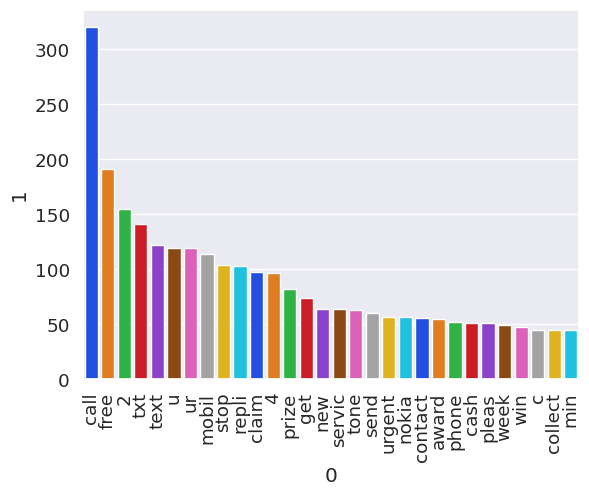

/tmp/ipykernel_31747/3108390142.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot( data = filter_ham_df , x = filter_ham_df[0] , y = filter_ham_df[1] , palette = 'cool')


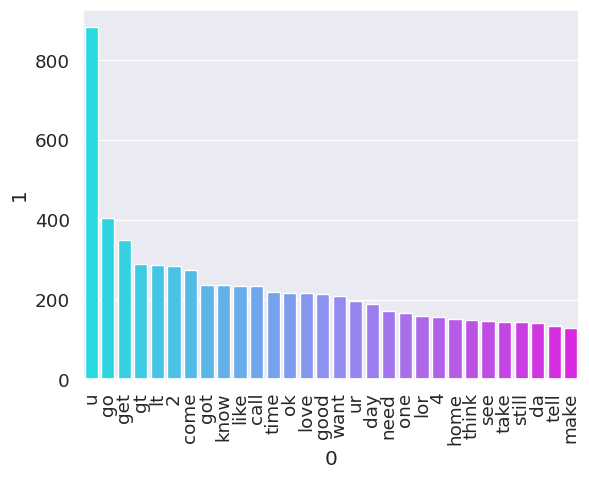

In [77]:
spam_carpos = []
for sentence in df[df['target'] == 1]['transform_text'].tolist():
  for word in sentence.split():
    spam_carpos.append(word )
from collections import Counter
filter_df = pd.DataFrame( Counter(spam_carpos).most_common(30) )
sns.barplot( data = filter_df , x = filter_df[0] , y = filter_df[1] , palette = 'bright')
plt.xticks( rotation = 90 )
plt.show()

ham_carpos = []
for sentence in df[df['target'] == 0]['transform_text'].tolist():
  for word in sentence.split():
    ham_carpos.append(word )
from collections import Counter
filter_ham_df = pd.DataFrame( Counter(ham_carpos).most_common(30) )
sns.barplot( data = filter_ham_df , x = filter_ham_df[0] , y = filter_ham_df[1] , palette = 'cool')
plt.xticks( rotation = 90 )
plt.show()

In [83]:
from sklearn.feature_extraction.text import CountVectorizer , TfidfVectorizer
cv = CountVectorizer()
tfid = TfidfVectorizer( max_features = 300 )
x = tfid.fit_transform(df['transformed_text']).toarray()
y = df['target'].values

In [86]:
from sklearn.model_selection import train_test_split
x_train , x_test , y_train , y_test = train_test_split( x , y , test_size = 0.2 , random_state = 2)

In [92]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier

In [93]:
svc = SVC(kernel = 'sigmoid' , gamma = 1.0)
knc = KNeighborsClassifier()
mnd = MultinomialNB()
dtc = DecisionTreeClassifier(max_depth = 5)
lrc = LogisticRegression( solver = 'liblinear' , penalty = 'l1')
rfc = RandomForestClassifier(n_estimators = 50 , random_state = 2)
abc = AdaBoostClassifier(n_estimators = 50 , random_state = 2)
bc = BaggingClassifier( n_estimators= 50 , random_state= 2 )
etc = ExtraTreesClassifier(n_estimators = 50 , random_state= 2)
gbdt = GradientBoostingClassifier(n_estimators = 50 , random_state = 2)
xgb = XGBClassifier(n_estimators = 50 , random_state = 2)

In [95]:
clfs = {
    'SVC' : svc,
    'KN' : knc,
    'NB' : mnd,
    'DT' : dtc,
    'LR' : lrc,
    'RF' : rfc,
    'adaboost' : abc,
    'bgc' : bc,
    'etc' : etc,
    'gbdt' : gbdt,
    'xgb' : xgb
}

In [97]:
from sklearn.metrics import accuracy_score , precision_score
def train_classifier( clf , x_train , y_train , x_test , y_test):
  clf.fit(x_train , y_train)
  y_pred = clf.predict(x_test)
  accuracy = accuracy_score(y_test , y_pred)
  precision = precision_score(y_test , y_pred)
  return accuracy , precision

In [98]:
accuracy_scores = []
precision_scores = []

for name , clf in clfs.items():
  curr_acc , curr_prec = train_classifier( clf , x_train , y_train , x_test , y_test )
  print()
  print( 'For: ' , name )
  print( 'Accuracy : ' , curr_acc )
  print( 'Precision : ' , curr_prec )

  accuracy_scores.append(curr_acc)
  precision_scores.append(curr_prec)


For:  SVC
Accuracy :  0.9593810444874274
Precision :  0.9137931034482759

For:  KN
Accuracy :  0.9448742746615088
Precision :  0.9655172413793104

For:  NB
Accuracy :  0.960348162475822
Precision :  0.9292035398230089

For:  DT
Accuracy :  0.9352030947775629
Precision :  0.865979381443299

For:  LR
Accuracy :  0.9622823984526112
Precision :  0.9380530973451328

For:  RF
Accuracy :  0.9593810444874274
Precision :  0.8934426229508197

For:  adaboost
Accuracy :  0.9187620889748549
Precision :  0.8461538461538461

For:  bgc
Accuracy :  0.9555125725338491
Precision :  0.8484848484848485

For:  etc
Accuracy :  0.9690522243713733
Precision :  0.9274193548387096

For:  gbdt
Accuracy :  0.9477756286266924
Precision :  0.9375

For:  xgb
Accuracy :  0.9680851063829787
Precision :  0.9646017699115044
